# Solar Wind Speed Forecasting — Coronal Hole Feature Impact

Evaluates whether 4-day-lagged coronal-hole features improve XGBoost solar wind speed predictions over the existing `4x3.csv` baseline:

- **Stage A**: 193Å/211Å EUV coronal-hole features (`renamed_no_proxy.csv`), ~10-year sample — used to validate the lag/merge methodology at scale.
- **Stage B**: HMI magnetogram global features (`global_R2/energy/entropy/variance`), ~11-year sample (2010-2020) spanning multiple solar-cycle regimes — the actual target question.
- **HSS-event split**: since coronal holes specifically drive recurrent high-speed streams, results are also broken out by whether the target hour falls inside a cataloged HSS event.

In [1]:
import re
import warnings
from datetime import timedelta
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.width', 140)
RANDOM_STATE = 42
LAG_DAYS = 4
TOLERANCE = pd.Timedelta(hours=48)
EMBARGO_DAYS = 60  # purge window for cross-regime eval: drop train rows within 2 months of a test region's boundary
rng = np.random.RandomState(RANDOM_STATE)

## 1. Load data

In [2]:
def sanitize_columns(df):
    """XGBoost rejects feature names containing [ ] ( ) , \" — strip them."""
    df = df.copy()
    cols = [re.sub(r'[\[\](),"]', '_', str(c)).replace(' ', '_') for c in df.columns]
    cols = [re.sub(r'_+', '_', c).strip('_') for c in cols]
    df.columns = cols
    return df


df_base = pd.read_csv('4x3.csv', index_col=0, parse_dates=True)
df_base = sanitize_columns(df_base)
y = df_base['speed']
X_base = df_base.drop(columns=['speed'])

df_euv = pd.read_csv('renamed_no_proxy.csv', index_col=0, parse_dates=True)
df_euv = sanitize_columns(df_euv)

hmi_files = ['hmi_2010-05-01_to_2010-12-31_6h.csv'] + [f'hmi_{yr}_6h.csv' for yr in
             [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]]
df_hmi = pd.concat([pd.read_csv(f, parse_dates=['timestamp']) for f in hmi_files], ignore_index=True)
df_hmi['timestamp'] = df_hmi['timestamp'].dt.tz_localize(None)
df_hmi = df_hmi.drop_duplicates(subset='timestamp').set_index('timestamp').sort_index()
df_hmi = sanitize_columns(df_hmi)

print(f"Base: {X_base.shape}, target range {y.index.min()} -> {y.index.max()}")
print(f"EUV:  {df_euv.shape}, range {df_euv.index.min()} -> {df_euv.index.max()}")
print(f"HMI:  {df_hmi.shape}, range {df_hmi.index.min()} -> {df_hmi.index.max()}")
print(f"y NaN: {y.isna().sum()}, X_base NaN total: {X_base.isna().sum().sum()}")

Base: (123456, 66), target range 2010-06-01 00:00:00 -> 2024-06-30 23:00:00
EUV:  (13229, 72), range 2010-05-13 00:00:00 -> 2019-12-31 18:00:00
HMI:  (15240, 4), range 2010-05-13 00:00:00 -> 2020-12-31 18:00:00
y NaN: 0, X_base NaN total: 0


## 2. Lag-and-merge utility

A feature observed at `T_obs` becomes a predictor for the target at `T_obs + lag_days` (consistent with the existing `magn(-28)`-style lag convention already in `4x3.csv`). The 6-hourly feature series is shifted forward by `lag_days`, then `merge_asof`'d onto the hourly target grid (forward-fill, capped at `tolerance` so a stale value isn't carried across a multi-month coverage gap).

In [3]:
def lag_and_merge(feature_df, lag_days, target_index, tolerance=TOLERANCE):
    shifted = feature_df.copy()
    shifted.index = shifted.index + pd.Timedelta(days=lag_days)
    shifted = shifted[~shifted.index.duplicated(keep='last')].sort_index()
    target_frame = pd.DataFrame(index=pd.DatetimeIndex(target_index).sort_values())
    merged = pd.merge_asof(target_frame, shifted, left_index=True, right_index=True,
                            direction='backward', tolerance=tolerance)
    return merged.reindex(target_index)


# Fixed hyperparameters from transfer/test.ipynb -- still used by the (untouched) cross-regime
# holdout further below, which is out of scope for the Optuna tuning introduced in this section.
TRANSFER_XGB_PARAMS = dict(
    n_estimators=500, max_depth=3, learning_rate=0.051212530070895795,
    subsample=0.505483952118673, colsample_bytree=0.6326585694513049,
    min_child_weight=4, gamma=2.243192029143412e-07,
    objective='reg:squarederror', tree_method='hist', early_stopping_rounds=50,
)

N_TRIALS_MAIN = 60    # Optuna trials per dataset for the main no_cme hyperparameter search
N_TRIALS_PER_K = 20   # Optuna trials per dataset per feature-count fraction in the pruning sweep


def cross_validation_split(Y, n_splits=5):
    """Verbatim from transfer/cross_validation.py: 5 equally sized chronological chunks, each
    used once as the test fold (train = all other chunks, including ones *after* the test
    chunk -- not a pure walk-forward split). A symmetric 180-day gap is carved out around every
    train/test boundary (90 days dropped from each side) to prevent near-boundary leakage."""
    dates = Y.index
    discard_len = 180
    discard_len = int(discard_len / 2)
    chunk_len = len(dates) // n_splits
    chunk_remainder = len(dates) % n_splits

    data_split = np.zeros((len(dates), n_splits), dtype=bool)
    for i in range(n_splits):
        data_split[i * chunk_len:(i + 1) * chunk_len, i] = True
    if chunk_remainder > 0:
        data_split[-chunk_remainder:, n_splits - 1] = True

    cv_train, cv_test = [], []
    for i in range(n_splits):
        test_data = np.copy(data_split[:, i])
        train_data = np.any(np.concatenate([data_split[:, :i], data_split[:, i + 1:]], axis=1), axis=1)
        if i == 0:
            test_data[chunk_len - discard_len * 24:chunk_len] = False
            train_data[chunk_len: chunk_len + discard_len * 24] = False
        elif i == (n_splits - 1):
            test_data[chunk_len * i:chunk_len * i + discard_len * 24] = False
            train_data[chunk_len * i - discard_len * 24: chunk_len * i] = False
        else:
            test_data[chunk_len * i: chunk_len * i + discard_len * 24] = False
            test_data[chunk_len * (i + 1) - discard_len * 24:chunk_len * (i + 1)] = False
            train_data[chunk_len * i - discard_len * 24: chunk_len * i] = False
            train_data[chunk_len * (i + 1): chunk_len * (i + 1) + discard_len * 24] = False

        cv_train.append(dates[train_data])
        cv_test.append(dates[test_data])

    return cv_train, cv_test


def delete_cmes_from_data_split(data_split, cme_list):
    """Verbatim from transfer/cross_validation.py: remove dates within a CME's start/end window
    or its 27-day solar-rotation recurrence echo from each fold's train and test dates."""
    train_split = deepcopy(data_split[0])
    test_split = deepcopy(data_split[1])
    n_folds = len(train_split)

    for i in range(n_folds):
        dates_train = train_split[i]
        dates_test = test_split[i]

        binary_cme_train = np.zeros(len(dates_train), dtype=bool)
        binary_cme_test = np.zeros(len(dates_test), dtype=bool)

        for j in range(cme_list.shape[0]):
            binary_cme_train |= ((cme_list.loc[j, 'start'] <= dates_train) & (cme_list.loc[j, 'end'] >= dates_train))
            binary_cme_train |= (((cme_list.loc[j, 'start'] + timedelta(days=26)) <= dates_train) &
                                  ((cme_list.loc[j, 'end'] + timedelta(days=28)) >= dates_train))
            binary_cme_test |= ((cme_list.loc[j, 'start'] <= dates_test) & (cme_list.loc[j, 'end'] >= dates_test))
            binary_cme_test |= (((cme_list.loc[j, 'start'] + timedelta(days=26)) <= dates_test) &
                                 ((cme_list.loc[j, 'end'] + timedelta(days=28)) >= dates_test))

        binary_cme_train = np.invert(binary_cme_train)
        binary_cme_test = np.invert(binary_cme_test)

        train_split[i] = dates_train[binary_cme_train]
        test_split[i] = dates_test[binary_cme_test]

    return [train_split, test_split]


def build_no_cme_folds(X, Y, cme_list, n_splits=5):
    """cross_validation_split + delete_cmes_from_data_split, keeping only the no_cme branch --
    the with_cme comparison is out of scope going forward."""
    cv_train, cv_test = cross_validation_split(Y, n_splits=n_splits)
    cv_train_no_cme, cv_test_no_cme = delete_cmes_from_data_split([cv_train, cv_test], cme_list)
    return cv_train_no_cme, cv_test_no_cme


def no_cme_dates(idx, cme_list):
    """Global (non-per-fold) CME-exclusion mask over an arbitrary date index, for full-data SHAP
    fits -- reuses delete_cmes_from_data_split with a degenerate single-fold split so there's no
    second CME-filtering implementation to maintain."""
    train_split, _ = delete_cmes_from_data_split([[idx], [idx]], cme_list)
    return train_split[0]


def xgb_cv_rmse(X, Y, params, train_dates_list, test_dates_list):
    """Fit/predict one XGBoost model per fold (eval_set=test fold for early stopping, matching
    the rest of the notebook). Returns (per-fold metrics df, oof predictions indexed by date)."""
    rows = []
    preds_all = []
    for fold, (train_dates, test_dates) in enumerate(zip(train_dates_list, test_dates_list)):
        assert len(train_dates.intersection(test_dates)) == 0, f"Leakage in fold {fold}"
        X_train, Y_train = X.loc[train_dates].copy(), Y.loc[train_dates]
        X_test, Y_test = X.loc[test_dates].copy(), Y.loc[test_dates]
        clean_cols = [str(c).replace('[', '').replace(']', '').replace('<', '').replace('>', '') for c in X_train.columns]
        X_train.columns = clean_cols
        X_test.columns = clean_cols

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, Y_train, eval_set=[(X_test, Y_test)], verbose=False)
        pred = pd.Series(model.predict(X_test), index=test_dates)
        preds_all.append(pred)

        cc = np.nan if np.std(pred.values) < 1e-8 else np.corrcoef(Y_test.values, pred.values)[0, 1]
        rows.append({
            'fold': fold, 'n_train': len(train_dates), 'n_test': len(test_dates),
            'rmse': np.sqrt(mean_squared_error(Y_test, pred)), 'mae': mean_absolute_error(Y_test, pred),
            'r2': r2_score(Y_test, pred), 'cc': cc,
        })
    oof_pred = pd.concat(preds_all).sort_index()
    return pd.DataFrame(rows), oof_pred


XGB_SEARCH_SPACE_FIXED = dict(n_estimators=500, objective='reg:squarederror', tree_method='hist',
                               early_stopping_rounds=50)


def tune_xgb_optuna(X, Y, cme_list, n_splits=5, n_trials=N_TRIALS_MAIN, seed=RANDOM_STATE):
    """Optuna (TPE) search over XGBoost hyperparameters, scored by mean RMSE across the no_cme
    folds (cross_validation_split + delete_cmes_from_data_split). Single-level: the same folds
    both select the winning trial and report its metrics -- a known optimistic-bias tradeoff (see
    markdown note above Stage A), consistent with this project's prior practice."""
    train_dates_list, test_dates_list = build_no_cme_folds(X, Y, cme_list, n_splits=n_splits)

    def objective(trial):
        params = dict(XGB_SEARCH_SPACE_FIXED)
        params['max_depth'] = trial.suggest_int('max_depth', 2, 8)
        params['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        params['subsample'] = trial.suggest_float('subsample', 0.4, 1.0)
        params['colsample_bytree'] = trial.suggest_float('colsample_bytree', 0.4, 1.0)
        params['min_child_weight'] = trial.suggest_int('min_child_weight', 1, 20)
        params['gamma'] = trial.suggest_float('gamma', 1e-8, 10.0, log=True)
        params['reg_lambda'] = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
        params['reg_alpha'] = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True)
        try:
            metrics_df, _ = xgb_cv_rmse(X, Y, params, train_dates_list, test_dates_list)
            return metrics_df['rmse'].mean()
        except Exception:
            return float('inf')

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = dict(XGB_SEARCH_SPACE_FIXED)
    best_params.update(study.best_params)
    cv_metrics, oof_pred = xgb_cv_rmse(X, Y, best_params, train_dates_list, test_dates_list)
    return {
        'best_params': best_params,
        'cv_metrics': cv_metrics,
        'cv_rmse_mean': cv_metrics['rmse'].mean(),
        'oof_pred': oof_pred,
    }


def feature_pruning_sweep(X, Y, cme_list, shap_ranking, k_fractions=(1.0, 0.75, 0.5, 0.25), n_trials=N_TRIALS_PER_K):
    """For each fraction, keep the top-K SHAP-ranked columns and retune from scratch (optimal
    hyperparameters can shift when feature count changes). Reports whether pruning helps -- does
    NOT modify X_base_euv/X_stageB_treatment/etc. used elsewhere in the notebook."""
    n_features = X.shape[1]
    rows = []
    for frac in k_fractions:
        k = max(1, round(frac * n_features))
        cols = [c for c in shap_ranking.index if c in X.columns][:k]
        result = tune_xgb_optuna(X[cols], Y, cme_list, n_trials=n_trials)
        rows.append({'frac': frac, 'k': k, 'n_features': len(cols), 'cv_rmse_mean': result['cv_rmse_mean'],
                     'best_params': result['best_params']})
    return pd.DataFrame(rows)


def oof_to_positional(oof_series, timestamps):
    """Map a date-indexed oof-prediction Series back onto the 0..n-1 positional index aligned
    with `timestamps` (a Series of dates in the same row order as the original positional X/y)."""
    date_to_pos = pd.Series(np.arange(len(timestamps)), index=pd.DatetimeIndex(timestamps.values))
    pos = date_to_pos.loc[oof_series.index].values
    result = pd.Series(np.nan, index=np.arange(len(timestamps)))
    result.iloc[pos] = oof_series.values
    return result


def fit_full_model(X, Y, params=None):
    """Fit on the full dataset (no holdout) for SHAP/diagnostic use -- early_stopping_rounds is
    dropped since there's no eval_set to stop against."""
    params = dict(params or TRANSFER_XGB_PARAMS)
    params.pop('early_stopping_rounds', None)
    model = xgb.XGBRegressor(**params)
    model.fit(X, Y)
    return model

## 2b. CME list (used per-fold below, transfer-style)

In [4]:
cme_list = pd.read_csv('enhancements/cme_list.csv', parse_dates=['start', 'end'])
print(f"Loaded {len(cme_list)} CME events ({cme_list['start'].min()} -> {cme_list['end'].max()}); "
      f"used per-fold below via delete_cmes_from_data_split (transfer-style no_cme vs with_cme comparison).")

Loaded 313 CME events (2000-01-21 17:00:00 -> 2024-01-06 03:00:00); used per-fold below via delete_cmes_from_data_split (transfer-style no_cme vs with_cme comparison).


## 3. Stage A — validate the pipeline on EUV features (large sample, ~10yr)

In [5]:
X_euv_lag4 = lag_and_merge(df_euv, LAG_DAYS, y.index, TOLERANCE).add_prefix('euv_')
print(f"EUV lag-4 merged: {X_euv_lag4.shape}, non-NaN rows: {X_euv_lag4.notna().any(axis=1).sum()} / {len(X_euv_lag4)}")

recurrence_27d = lag_and_merge(y.to_frame('speed'), 27, y.index, tolerance=pd.Timedelta(hours=2))
recurrence_27d = recurrence_27d.rename(columns={'speed': 'speed_recur_27d'})
print(f"27-day recurrence non-NaN: {recurrence_27d['speed_recur_27d'].notna().sum()} / {len(recurrence_27d)}")

EUV lag-4 merged: (123456, 72), non-NaN rows: 83867 / 123456
27-day recurrence non-NaN: 122808 / 123456


**Note on methodology below**: hyperparameters are now tuned per dataset with Optuna (TPE sampler, no_cme scenario only) instead of reusing one fixed hyperparameter set borrowed from `transfer/test.ipynb`. This is single-level CV -- the same 5 no_cme folds both select the winning trial and report its metrics, so the reported RMSE is mildly optimistic vs. a true nested-CV estimate (a 60-trial search can exploit fold idiosyncrasies in a way fixed hyperparameters couldn't). This tradeoff is consistent with this project's prior practice, but worth keeping in mind. The `with_cme` comparison and the cross-regime holdout (further below) are out of scope for this change: `with_cme` is no longer computed at all, and the cross-regime holdout still uses the original fixed `TRANSFER_XGB_PARAMS`.

In [6]:
cv_range = y.index < pd.Timestamp('2020-01-01')  # eval_mode='cv' in transfer/test.ipynb -- solar cycle 24 only
print(f"Stage A base-only: Optuna-tuned CV (cross_validation_split, 180-day gap, no_cme only), "
      f"restricted to <2020-01-01 ({cv_range.sum()} rows)...")
tune_base_only = tune_xgb_optuna(X_base.loc[cv_range], y.loc[cv_range], cme_list)
oof_base_only = tune_base_only['oof_pred']
print(tune_base_only['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean())
print(f"Best params: {tune_base_only['best_params']}")

print("\nStage A base+EUV: Optuna-tuned CV (same <2020-01-01 restriction)...")
X_base_euv = pd.concat([X_base, X_euv_lag4], axis=1)
tune_base_euv = tune_xgb_optuna(X_base_euv.loc[cv_range], y.loc[cv_range], cme_list)
oof_base_euv = tune_base_euv['oof_pred']
print(tune_base_euv['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean())
print(f"Best params: {tune_base_euv['best_params']}")

valid = recurrence_27d['speed_recur_27d'].notna() & cv_range
recur_rmse = np.sqrt(mean_squared_error(y[valid], recurrence_27d.loc[valid, 'speed_recur_27d']))
recur_mae = mean_absolute_error(y[valid], recurrence_27d.loc[valid, 'speed_recur_27d'])
recur_r2 = r2_score(y[valid], recurrence_27d.loc[valid, 'speed_recur_27d'])

summary_stageA = pd.DataFrame({
    'base_only_no_cme': tune_base_only['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean(),
    'base_plus_euv_no_cme': tune_base_euv['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean(),
}).T
summary_stageA.loc['recurrence_27d_naive', ['rmse', 'mae', 'r2']] = [recur_rmse, recur_mae, recur_r2]
print("\nStage A summary (Optuna-tuned per-dataset hyperparameters, no_cme only):")
summary_stageA

Stage A base-only: Optuna-tuned CV (cross_validation_split, 180-day gap, no_cme only), restricted to <2020-01-01 (84024 rows)...


rmse    65.839723
mae     51.251373
r2       0.397133
cc       0.637415
dtype: float64
Best params: {'n_estimators': 500, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'early_stopping_rounds': 50, 'max_depth': 2, 'learning_rate': 0.14941465895804926, 'subsample': 0.5345838133681151, 'colsample_bytree': 0.4299400095209767, 'min_child_weight': 2, 'gamma': 0.0003097682351708914, 'reg_lambda': 0.04426733943453374, 'reg_alpha': 0.0050621092016956745}

Stage A base+EUV: Optuna-tuned CV (same <2020-01-01 restriction)...


rmse    65.096732
mae     50.745467
r2       0.402347
cc       0.639332
dtype: float64
Best params: {'n_estimators': 500, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'early_stopping_rounds': 50, 'max_depth': 4, 'learning_rate': 0.04454885154044163, 'subsample': 0.6062498825279353, 'colsample_bytree': 0.5441107006038166, 'min_child_weight': 14, 'gamma': 6.075544878656133e-07, 'reg_lambda': 0.22677879265232728, 'reg_alpha': 0.0017310979406171341}

Stage A summary (Optuna-tuned per-dataset hyperparameters, no_cme only):


,rmse,mae,r2,cc
base_only_no_cme,65.839723,51.251373,0.397133,0.637415
base_plus_euv_no_cme,65.096732,50.745467,0.402347,0.639332
recurrence_27d_naive,98.683481,72.973865,-0.123369,NaN


Computing SHAP for base+EUV model (no_cme-filtered, Optuna-tuned hyperparameters)...


Best-ranked EUV feature: euv_193_Area_CH_pix_2_2 at rank 6 of 138
EUV features in top 20: 7


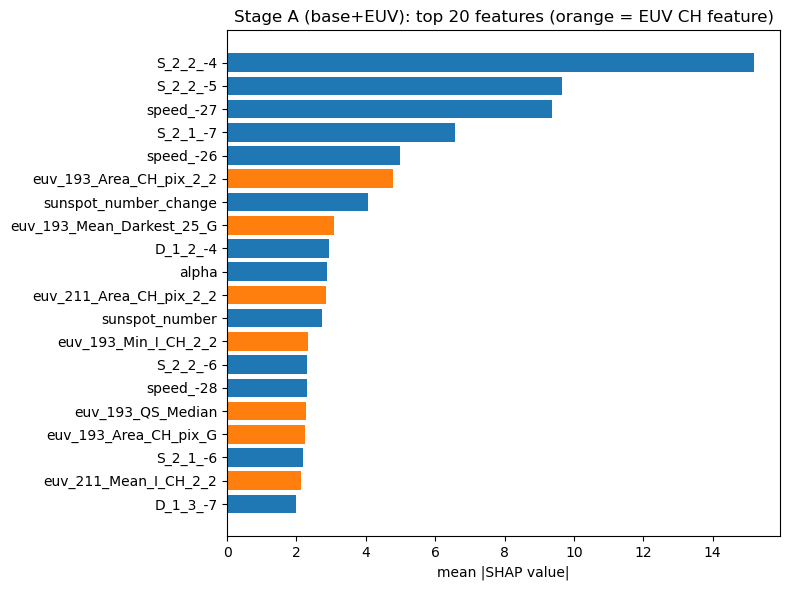


Computing SHAP for base-only model (no_cme-filtered, Optuna-tuned hyperparameters)...


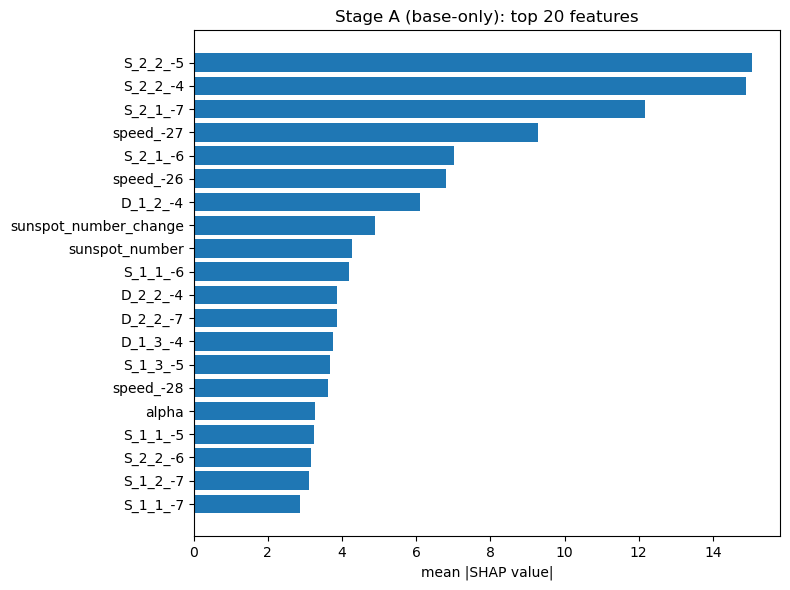

In [7]:
print("Computing SHAP for base+EUV model (no_cme-filtered, Optuna-tuned hyperparameters)...")
euv_fit_dates = no_cme_dates(X_base_euv.loc[cv_range].index, cme_list)
X_base_euv_nocme = X_base_euv.loc[euv_fit_dates]
y_nocme_for_euv = y.loc[euv_fit_dates]
model_euv_full = fit_full_model(X_base_euv_nocme, y_nocme_for_euv, params=tune_base_euv['best_params'])
sample_idx = rng.choice(len(X_base_euv_nocme), size=min(3000, len(X_base_euv_nocme)), replace=False)
X_sample = X_base_euv_nocme.iloc[sample_idx]
explainer = shap.TreeExplainer(model_euv_full)
shap_values = explainer.shap_values(X_sample)

mean_abs_shap_euv = pd.Series(np.abs(shap_values).mean(axis=0), index=X_base_euv_nocme.columns).sort_values(ascending=False)
euv_cols = [c for c in X_base_euv_nocme.columns if c.startswith('euv_')]
euv_rank = mean_abs_shap_euv.rank(ascending=False)
print(f"Best-ranked EUV feature: {euv_rank[euv_cols].idxmin()} at rank {int(euv_rank[euv_cols].min())} of {len(mean_abs_shap_euv)}")
print(f"EUV features in top 20: {sum(c in mean_abs_shap_euv.head(20).index for c in euv_cols)}")

top20 = mean_abs_shap_euv.head(20)
colors = ['tab:orange' if c.startswith('euv_') else 'tab:blue' for c in top20.index]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('mean |SHAP value|')
ax.set_title('Stage A (base+EUV): top 20 features (orange = EUV CH feature)')
plt.tight_layout()
plt.show()

print("\nComputing SHAP for base-only model (no_cme-filtered, Optuna-tuned hyperparameters)...")
base_only_fit_dates = no_cme_dates(X_base.loc[cv_range].index, cme_list)
X_base_nocme = X_base.loc[base_only_fit_dates]
y_nocme_for_base = y.loc[base_only_fit_dates]
model_base_only_full = fit_full_model(X_base_nocme, y_nocme_for_base, params=tune_base_only['best_params'])
sample_idx_base = rng.choice(len(X_base_nocme), size=min(3000, len(X_base_nocme)), replace=False)
X_sample_base = X_base_nocme.iloc[sample_idx_base]
explainer_base = shap.TreeExplainer(model_base_only_full)
shap_values_base = explainer_base.shap_values(X_sample_base)
mean_abs_shap_base_only = pd.Series(np.abs(shap_values_base).mean(axis=0), index=X_base_nocme.columns).sort_values(ascending=False)

top20_base = mean_abs_shap_base_only.head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_base.index[::-1], top20_base.values[::-1], color='tab:blue')
ax.set_xlabel('mean |SHAP value|')
ax.set_title('Stage A (base-only): top 20 features')
plt.tight_layout()
plt.show()

### 3b. Feature-pruning sweep (Stage A, no_cme)

For each dataset, keep only the top-K SHAP-ranked features (K = 100/75/50/25% of the full feature count) and retune from scratch. This checks whether the bottom-ranked features are actually pulling their weight, or whether a smaller feature set does just as well (or better). The `frac=1.0` row is a built-in consistency check against the main search above. This is diagnostic only -- it does not change the feature sets used elsewhere in the notebook.

In [8]:
print("Feature-pruning sweep: base+EUV (no_cme, retuned per feature-count fraction)...")
sweep_base_euv = feature_pruning_sweep(X_base_euv.loc[cv_range], y.loc[cv_range], cme_list, mean_abs_shap_euv)
print(sweep_base_euv[['frac', 'k', 'n_features', 'cv_rmse_mean']])

print("\nFeature-pruning sweep: base-only (no_cme, retuned per feature-count fraction)...")
sweep_base_only = feature_pruning_sweep(X_base.loc[cv_range], y.loc[cv_range], cme_list, mean_abs_shap_base_only)
print(sweep_base_only[['frac', 'k', 'n_features', 'cv_rmse_mean']])

Feature-pruning sweep: base+EUV (no_cme, retuned per feature-count fraction)...


   frac    k  n_features  cv_rmse_mean
0  1.00  138         138     65.272374
1  0.75  104         104     64.869038
2  0.50   69          69     64.339254
3  0.25   34          34     63.761612

Feature-pruning sweep: base-only (no_cme, retuned per feature-count fraction)...


   frac   k  n_features  cv_rmse_mean
0  1.00  66          66     66.184849
1  0.75  50          50     65.875606
2  0.50  33          33     65.967798
3  0.25  16          16     66.299974


## 4. Stage B — HMI magnetogram features (multi-year, multi-regime sample)

In [9]:
X_hmi_lag4 = lag_and_merge(df_hmi, LAG_DAYS, y.index, TOLERANCE).add_prefix('hmi_')
hmi_mask = X_hmi_lag4.notna().any(axis=1)
print(f"HMI lag-4 merged: non-NaN rows {hmi_mask.sum()} / {len(X_hmi_lag4)}")

hmi_valid_idx = y.index[hmi_mask]
# With 2010-2020 now continuously covered, year-boundary timestamp gaps vanish (Dec 31 -> Jan 1
# is only 6h), so the old gap-detection regime split collapses to a single regime. Use calendar
# year as the regime label instead -- a natural multi-way extension of the original
# "train on one solar-cycle phase, test on another" idea now that 11 years are available.
regime_id = pd.Series(hmi_valid_idx).dt.year
print(f"Detected {regime_id.nunique()} regime windows (by calendar year):")
for rid, grp in pd.Series(hmi_valid_idx).groupby(regime_id.values):
    print(f"  regime {rid}: {grp.min()} -> {grp.max()} ({len(grp)} rows)")

X_stageB_control = X_base_euv.loc[hmi_mask].reset_index(drop=True)
X_stageB_treatment = pd.concat([X_base_euv, X_hmi_lag4], axis=1).loc[hmi_mask].reset_index(drop=True)
y_stageB = y.loc[hmi_mask].reset_index(drop=True)
regime_stageB = regime_id.values
# positionally aligned with the X_stageB_*/y_stageB row order above, for the CV embargo
stageB_timestamps = pd.Series(hmi_valid_idx).reset_index(drop=True)
print(f"\nStage B dataset: {X_stageB_control.shape[0]} rows")

X_stageB_control_dt = X_stageB_control.set_index(pd.DatetimeIndex(stageB_timestamps.values))
X_stageB_treatment_dt = X_stageB_treatment.set_index(pd.DatetimeIndex(stageB_timestamps.values))
y_stageB_dt = pd.Series(y_stageB.values, index=X_stageB_control_dt.index)

HMI lag-4 merged: non-NaN rows 92679 / 123456
Detected 12 regime windows (by calendar year):
  regime 2010: 2010-06-01 00:00:00 -> 2010-12-31 23:00:00 (5136 rows)
  regime 2011: 2011-01-01 00:00:00 -> 2011-12-31 23:00:00 (8760 rows)
  regime 2012: 2012-01-01 00:00:00 -> 2012-12-31 23:00:00 (8784 rows)
  regime 2013: 2013-01-01 00:00:00 -> 2013-12-31 23:00:00 (8647 rows)
  regime 2014: 2014-01-01 00:00:00 -> 2014-12-31 23:00:00 (8760 rows)
  regime 2015: 2015-01-01 00:00:00 -> 2015-12-31 23:00:00 (8760 rows)
  regime 2016: 2016-01-01 00:00:00 -> 2016-12-31 23:00:00 (8629 rows)
  regime 2017: 2017-01-01 00:00:00 -> 2017-12-31 23:00:00 (8760 rows)
  regime 2018: 2018-01-01 00:00:00 -> 2018-12-31 23:00:00 (8760 rows)
  regime 2019: 2019-01-01 00:00:00 -> 2019-12-31 23:00:00 (8760 rows)
  regime 2020: 2020-01-01 00:00:00 -> 2020-12-31 23:00:00 (8784 rows)
  regime 2021: 2021-01-01 00:00:00 -> 2021-01-06 18:00:00 (139 rows)

Stage B dataset: 92679 rows


In [10]:
cv_range_b = y_stageB_dt.index < pd.Timestamp('2020-01-01')  # same eval_mode='cv' restriction as Stage A
print(f"Stage B control (no HMI): Optuna-tuned CV (cross_validation_split, 180-day gap, no_cme only), "
      f"restricted to <2020-01-01 ({cv_range_b.sum()} rows)...")
tune_control = tune_xgb_optuna(X_stageB_control_dt.loc[cv_range_b], y_stageB_dt.loc[cv_range_b], cme_list)
oof_control = tune_control['oof_pred']
print(tune_control['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean())
print(f"Best params: {tune_control['best_params']}")

print("\nStage B treatment (+HMI): Optuna-tuned CV (same <2020-01-01 restriction)...")
tune_treatment = tune_xgb_optuna(X_stageB_treatment_dt.loc[cv_range_b], y_stageB_dt.loc[cv_range_b], cme_list)
oof_treatment = tune_treatment['oof_pred']
print(tune_treatment['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean())
print(f"Best params: {tune_treatment['best_params']}")

cv_summary_stageB = pd.DataFrame({
    'control_no_cme': tune_control['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean(),
    'treatment_no_cme': tune_treatment['cv_metrics'][['rmse', 'mae', 'r2', 'cc']].mean(),
}).T
cv_summary_stageB

Stage B control (no HMI): Optuna-tuned CV (cross_validation_split, 180-day gap, no_cme only), restricted to <2020-01-01 (83756 rows)...


rmse    64.984347
mae     50.770703
r2       0.403677
cc       0.639187
dtype: float64
Best params: {'n_estimators': 500, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'early_stopping_rounds': 50, 'max_depth': 3, 'learning_rate': 0.06378136028950993, 'subsample': 0.49356025976321166, 'colsample_bytree': 0.9123517140173995, 'min_child_weight': 6, 'gamma': 1.9707312324360422, 'reg_lambda': 0.052214933401266754, 'reg_alpha': 0.04358445962568922}

Stage B treatment (+HMI): Optuna-tuned CV (same <2020-01-01 restriction)...


rmse    65.159482
mae     50.932110
r2       0.401120
cc       0.640086
dtype: float64
Best params: {'n_estimators': 500, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'early_stopping_rounds': 50, 'max_depth': 3, 'learning_rate': 0.07640176043372574, 'subsample': 0.47615116507026667, 'colsample_bytree': 0.6104992281616074, 'min_child_weight': 3, 'gamma': 2.040967288954294, 'reg_lambda': 3.9051952669913788, 'reg_alpha': 1.393978675022225}


,rmse,mae,r2,cc
control_no_cme,64.984347,50.770703,0.403677,0.639187
treatment_no_cme,65.159482,50.932110,0.401120,0.640086


In [11]:
def cross_regime_eval(X, y_target, regime_labels, train_regime, test_regime, timestamps,
                       params=None, embargo_days=EMBARGO_DAYS):
    """Train on one regime, test on another. Regimes are disjoint calendar years, but for
    adjacent years the lag-and-merge tolerance window can let feature data spill across the
    Dec31->Jan1 boundary. Embargo: drop any train row within `embargo_days` of the test
    regime's date range -- a no-op for non-adjacent regime pairs. Fixed transfer-style
    hyperparameters and eval_set=test-fold early stopping, matching the rest of the notebook."""
    params = params or TRANSFER_XGB_PARAMS
    train_mask = regime_labels == train_regime
    test_mask = regime_labels == test_regime
    train_idx_all = np.where(train_mask)[0]
    test_idx = np.where(test_mask)[0]

    if embargo_days:
        test_start = timestamps.iloc[test_idx].min()
        test_end = timestamps.iloc[test_idx].max()
        embargo = pd.Timedelta(days=embargo_days)
        train_ts = timestamps.iloc[train_idx_all]
        keep = (train_ts < test_start - embargo) | (train_ts > test_end + embargo)
        train_idx = train_idx_all[keep.values]
    else:
        train_idx = train_idx_all

    X_train, y_train = X.iloc[train_idx], y_target.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y_target.iloc[test_idx]
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    pred = model.predict(X_test)
    full_pred = pd.Series(np.nan, index=np.arange(len(y_target)))
    full_pred.iloc[test_idx] = pred
    cc = np.nan if np.std(pred) < 1e-8 else np.corrcoef(y_test.values, pred)[0, 1]
    return {
        'rmse': np.sqrt(mean_squared_error(y_test, pred)),
        'mae': mean_absolute_error(y_test, pred),
        'r2': r2_score(y_test, pred),
        'cc': cc,
        'n_train': int(len(train_idx)), 'n_test': int(len(test_idx)),
        'n_embargoed': int(len(train_idx_all) - len(train_idx)),
    }, full_pred


MIN_REGIME_ROWS = 1000  # drop degenerate dataset-boundary slivers (e.g. a 139-row stray tail
                         # year) from cross-regime eval -- with the embargo, a regime smaller
                         # than the embargo window can lose ALL its rows as a train set, crashing
regime_counts = pd.Series(regime_stageB).value_counts()
regimes_all = sorted(pd.unique(regime_stageB))
regimes = [r for r in regimes_all if regime_counts[r] >= MIN_REGIME_ROWS]
dropped_regimes = [r for r in regimes_all if r not in regimes]
print(f"Regimes found: {regimes_all} (each a contiguous HMI coverage window, gap-detected at >30 days)")
if dropped_regimes:
    print(f"Excluding from cross-regime eval (< {MIN_REGIME_ROWS} rows, dataset-boundary slivers): "
          f"{[(r, int(regime_counts[r])) for r in dropped_regimes]}")
print(f"Using transfer-style fixed hyperparameters, eval_set=test-fold early stopping, "
      f"{EMBARGO_DAYS}-day train/test embargo for cross-regime holdout.")

cross_results = []
cross_preds = {}
for train_r in regimes:
    for test_r in regimes:
        if train_r == test_r:
            continue
        res_control, pred_control = cross_regime_eval(X_stageB_control, y_stageB, regime_stageB, train_r, test_r,
                                                        timestamps=stageB_timestamps)
        res_treat, pred_treat = cross_regime_eval(X_stageB_treatment, y_stageB, regime_stageB, train_r, test_r,
                                                    timestamps=stageB_timestamps)
        cross_results.append({'train_regime': train_r, 'test_regime': test_r, 'variant': 'control', **res_control})
        cross_results.append({'train_regime': train_r, 'test_regime': test_r, 'variant': 'treatment', **res_treat})
        cross_preds[(train_r, test_r, 'control')] = pred_control
        cross_preds[(train_r, test_r, 'treatment')] = pred_treat

cross_df = pd.DataFrame(cross_results)
print("\nCross-regime holdout (train on one solar-cycle phase, test on the other):")
print(f"Total train rows dropped to embargo across all pairs: {cross_df['n_embargoed'].sum()}")
cross_df

Regimes found: [np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)] (each a contiguous HMI coverage window, gap-detected at >30 days)
Excluding from cross-regime eval (< 1000 rows, dataset-boundary slivers): [(np.int32(2021), 139)]
Using transfer-style fixed hyperparameters, eval_set=test-fold early stopping, 60-day train/test embargo for cross-regime holdout.



Cross-regime holdout (train on one solar-cycle phase, test on the other):
Total train rows dropped to embargo across all pairs: 57600


,train_regime,test_regime,variant,rmse,mae,r2,cc,n_train,n_test,n_embargoed
0,2010,2011,control,84.733772,65.867614,0.118539,0.355673,3696,8760,1440
1,2010,2011,treatment,85.885411,66.756408,0.094416,0.314850,3696,8760,1440
2,2010,2012,control,86.286344,68.302832,0.014667,0.186419,5136,8784,0
3,2010,2012,treatment,84.889730,66.159670,0.046306,0.280171,5136,8784,0
4,2010,2013,control,87.595369,72.867793,-0.000704,0.388357,5136,8647,0
...,...,...,...,...,...,...,...,...,...,...
215,2020,2017,treatment,90.206666,74.759133,0.322953,0.602525,8784,8760,0
216,2020,2018,control,70.443421,56.799326,0.267537,0.532109,8784,8760,0
217,2020,2018,treatment,73.490316,59.822627,0.202804,0.472672,8784,8760,0
218,2020,2019,control,62.306622,47.347026,0.353859,0.600255,7344,8760,1440


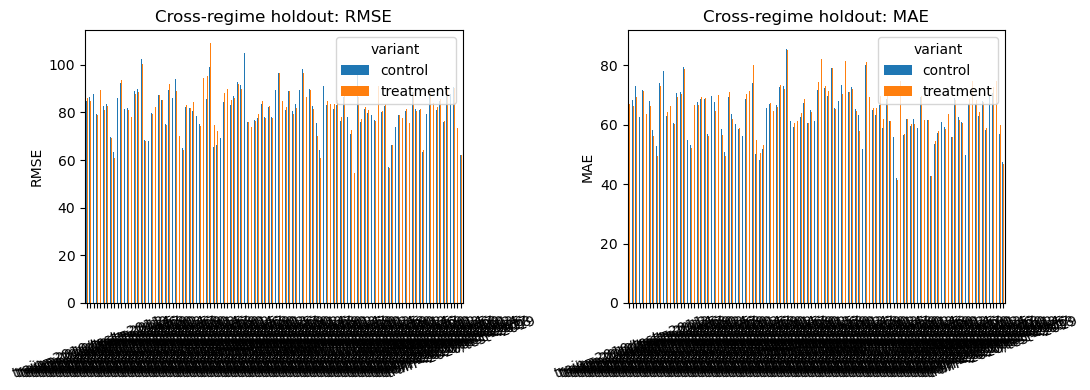

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ['rmse', 'mae']):
    pivot = cross_df.pivot_table(index=['train_regime', 'test_regime'], columns='variant', values=metric)
    pivot.index = [f"train={t}/test={s}" for t, s in pivot.index]
    pivot.plot(kind='bar', ax=ax)
    ax.set_title(f'Cross-regime holdout: {metric.upper()}')
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [13]:
print("SHAP for treatment model (no_cme-filtered, Optuna-tuned hyperparameters)...")
treatment_fit_dates = no_cme_dates(X_stageB_treatment_dt.loc[cv_range_b].index, cme_list)
X_treatment_nocme = X_stageB_treatment_dt.loc[treatment_fit_dates]
y_nocme_for_treatment = y_stageB_dt.loc[treatment_fit_dates]
model_hmi_full = fit_full_model(X_treatment_nocme, y_nocme_for_treatment, params=tune_treatment['best_params'])
sample_idx_b = rng.choice(len(X_treatment_nocme), size=min(2000, len(X_treatment_nocme)), replace=False)
X_sample_b = X_treatment_nocme.iloc[sample_idx_b]
explainer_b = shap.TreeExplainer(model_hmi_full)
shap_values_b = explainer_b.shap_values(X_sample_b)
mean_abs_shap_treatment = pd.Series(np.abs(shap_values_b).mean(axis=0), index=X_treatment_nocme.columns).sort_values(ascending=False)

hmi_cols = [c for c in X_treatment_nocme.columns if c.startswith('hmi_')]
print(f"HMI feature ranks (of {len(mean_abs_shap_treatment)} total features):")
print(mean_abs_shap_treatment.rank(ascending=False)[hmi_cols])

print("\nCorrelation: HMI features vs EUV CH-area features (low |corr| = HMI adds non-redundant information)")
euv_area_cols = [c for c in X_treatment_nocme.columns if 'Area_CH_pix_G' in c]
corr = X_treatment_nocme[hmi_cols + euv_area_cols].corr().loc[hmi_cols, euv_area_cols]
print(corr)

print("\nSHAP for control model (no HMI, no_cme-filtered, Optuna-tuned hyperparameters)...")
control_fit_dates = no_cme_dates(X_stageB_control_dt.loc[cv_range_b].index, cme_list)
X_control_nocme = X_stageB_control_dt.loc[control_fit_dates]
y_nocme_for_control = y_stageB_dt.loc[control_fit_dates]
model_control_full = fit_full_model(X_control_nocme, y_nocme_for_control, params=tune_control['best_params'])
sample_idx_c = rng.choice(len(X_control_nocme), size=min(2000, len(X_control_nocme)), replace=False)
X_sample_c = X_control_nocme.iloc[sample_idx_c]
explainer_c = shap.TreeExplainer(model_control_full)
shap_values_c = explainer_c.shap_values(X_sample_c)
mean_abs_shap_control = pd.Series(np.abs(shap_values_c).mean(axis=0), index=X_control_nocme.columns).sort_values(ascending=False)
print(f"\nControl model top-20 features:")
print(mean_abs_shap_control.head(20))

SHAP for treatment model (no_cme-filtered, Optuna-tuned hyperparameters)...


HMI feature ranks (of 142 total features):
hmi_global_R2           24.0
hmi_global_energy       42.0
hmi_global_entropy     130.0
hmi_global_variance     79.0
dtype: float64

Correlation: HMI features vs EUV CH-area features (low |corr| = HMI adds non-redundant information)
                     euv_193_Area_CH_pix_G  euv_211_Area_CH_pix_G
hmi_global_R2                    -0.191621              -0.191618
hmi_global_energy                -0.190653              -0.190653
hmi_global_entropy               -0.412869              -0.412870
hmi_global_variance              -0.189925              -0.189925

SHAP for control model (no HMI, no_cme-filtered, Optuna-tuned hyperparameters)...



Control model top-20 features:
S_2_2_-4                     15.230519
S_2_2_-5                      9.820183
speed_-27                     9.555673
S_2_1_-7                      6.841496
speed_-26                     5.259298
sunspot_number_change         5.105370
euv_193_Area_CH_pix_2_2       4.683732
euv_193_Mean_Darkest_25_G     3.517376
euv_193_Area_CH_pix_G         3.444350
alpha                         3.352897
euv_211_Min_I_CH_2_2          3.020823
sunspot_number                2.980492
euv_211_QS_Median             2.951828
D_1_2_-4                      2.896807
S_2_1_-6                      2.677001
euv_211_Mean_I_CH_2_2         2.658290
D_1_3_-7                      2.383505
speed_-28                     2.271215
euv_211_Mean_I_CH_1_1         2.225043
D_2_2_-4                      2.224145
dtype: float32


### 4b. Feature-pruning sweep (Stage B, no_cme)

Same top-K-by-SHAP-rank retuning sweep as Stage A, applied to the control and treatment datasets.

In [14]:
print("Feature-pruning sweep: treatment (+HMI, no_cme, retuned per feature-count fraction)...")
sweep_treatment = feature_pruning_sweep(X_stageB_treatment_dt.loc[cv_range_b], y_stageB_dt.loc[cv_range_b], cme_list, mean_abs_shap_treatment)
print(sweep_treatment[['frac', 'k', 'n_features', 'cv_rmse_mean']])

print("\nFeature-pruning sweep: control (no HMI, no_cme, retuned per feature-count fraction)...")
sweep_control = feature_pruning_sweep(X_stageB_control_dt.loc[cv_range_b], y_stageB_dt.loc[cv_range_b], cme_list, mean_abs_shap_control)
print(sweep_control[['frac', 'k', 'n_features', 'cv_rmse_mean']])

Feature-pruning sweep: treatment (+HMI, no_cme, retuned per feature-count fraction)...


   frac    k  n_features  cv_rmse_mean
0  1.00  142         142     65.272781
1  0.75  106         106     65.043034
2  0.50   71          71     64.542161
3  0.25   36          36     64.220865

Feature-pruning sweep: control (no HMI, no_cme, retuned per feature-count fraction)...


   frac    k  n_features  cv_rmse_mean
0  1.00  138         138     65.082899
1  0.75  104         104     64.841345
2  0.50   69          69     64.441769
3  0.25   34          34     64.010432


## 5. HSS-event-focused evaluation

Coronal holes specifically drive recurrent high-speed streams, so any genuine lift from CH features should concentrate during cataloged HSS events. All metrics below use genuinely out-of-sample predictions (out-of-fold CV or cross-regime holdout test predictions) — never an in-sample refit.

In [15]:
hss = pd.read_csv('enhancements/hss_list.csv', parse_dates=['start', 'end']).dropna(subset=['start', 'end'])
intervals = pd.IntervalIndex.from_arrays(hss['start'], hss['end'], closed='both')


def flag_events(index, intervals):
    return intervals.get_indexer(index) >= 0


hss_flag_full = pd.Series(flag_events(y.index, intervals), index=y.index)
hss_flag_stageB = pd.Series(flag_events(y.index[hmi_mask], intervals)).reset_index(drop=True)
print(f"HSS-flagged hours (full base period): {hss_flag_full.sum()} / {len(hss_flag_full)}")
print(f"HSS-flagged hours (Stage B window): {hss_flag_stageB.sum()} / {len(hss_flag_stageB)}")


def split_metrics_from_oof(oof_pred, y_target, event_flag):
    """oof_pred, y_target, event_flag must share the same positional (0..n-1) alignment."""
    valid = oof_pred.notna().values
    out = {}
    for label, mask in [('hss_event', event_flag.values & valid), ('non_event', (~event_flag.values) & valid)]:
        if mask.sum() == 0:
            continue
        out[label] = {
            'rmse': np.sqrt(mean_squared_error(y_target.values[mask], oof_pred.values[mask])),
            'mae': mean_absolute_error(y_target.values[mask], oof_pred.values[mask]),
            'n': int(mask.sum())
        }
    return out

HSS-flagged hours (full base period): 37749 / 123456
HSS-flagged hours (Stage B window): 27553 / 92679


In [16]:
print("Stage A (base+EUV) split by HSS event:")
stageA_hss = pd.DataFrame(split_metrics_from_oof(oof_base_euv.reindex(y.index), y, hss_flag_full)).T
print(stageA_hss)

print("\nStage B time-series CV, split by HSS event:")
print("control (no HMI):")
stageB_cv_control_hss = pd.DataFrame(split_metrics_from_oof(
    oof_to_positional(oof_control, stageB_timestamps), y_stageB, hss_flag_stageB)).T
print(stageB_cv_control_hss)
print("treatment (with HMI):")
stageB_cv_treatment_hss = pd.DataFrame(split_metrics_from_oof(
    oof_to_positional(oof_treatment, stageB_timestamps), y_stageB, hss_flag_stageB)).T
print(stageB_cv_treatment_hss)

print("\nStage B cross-regime holdout, split by HSS event:")
cross_hss_rows = []
for (train_r, test_r, variant), pred in cross_preds.items():
    res = split_metrics_from_oof(pred, y_stageB, hss_flag_stageB)
    for event_label, metrics in res.items():
        cross_hss_rows.append({'train_regime': train_r, 'test_regime': test_r, 'variant': variant,
                                'event': event_label, **metrics})
cross_hss_df = pd.DataFrame(cross_hss_rows)
cross_hss_df.to_csv('stageB_cross_regime_hss_split_full.csv', index=False)

print("\nAggregate (mean over all year-pairs, weighted equally per pair) by variant x event:")
print(cross_hss_df.groupby(['variant', 'event'])[['rmse', 'mae']].mean())
cross_hss_df

Stage A (base+EUV) split by HSS event:
                rmse        mae        n
hss_event  78.504336  61.411967  14695.0
non_event  55.185048  43.182601  22773.0

Stage B time-series CV, split by HSS event:
control (no HMI):
                rmse        mae        n
hss_event  77.917013  61.158548  14680.0
non_event  55.371335  43.401431  22630.0
treatment (with HMI):
                rmse        mae        n
hss_event  78.716155  61.750263  14680.0
non_event  55.028975  43.269388  22630.0

Stage B cross-regime holdout, split by HSS event:



Aggregate (mean over all year-pairs, weighted equally per pair) by variant x event:
                          rmse        mae
variant   event                          
control   hss_event  89.789482  69.731660
          non_event  76.121186  61.936689
treatment hss_event  90.377424  70.186148
          non_event  76.106981  61.784137


,train_regime,test_regime,variant,event,rmse,mae,n
0,2010,2011,control,hss_event,92.348466,72.381231,1835
1,2010,2011,control,non_event,82.598447,64.141623,6925
2,2010,2011,treatment,hss_event,96.220943,74.510621,1835
3,2010,2011,treatment,non_event,82.931079,64.701681,6925
4,2010,2012,control,hss_event,75.823093,55.982613,1568
...,...,...,...,...,...,...,...
435,2020,2018,treatment,non_event,65.580360,55.506935,5509
436,2020,2019,control,hss_event,76.614316,59.632492,3116
437,2020,2019,control,non_event,52.770811,40.564335,5644
438,2020,2019,treatment,hss_event,76.863416,59.053918,3116


## 6. Summary

In [17]:
print("="*70)
print("STAGE A - full ~10yr EUV-covered period, Optuna-tuned per-dataset hyperparameters, no_cme only")
print("="*70)
print(summary_stageA)
print(f"\nBest params -- base_only: {tune_base_only['best_params']}")
print(f"Best params -- base+EUV: {tune_base_euv['best_params']}")

print("\n" + "="*70)
print("STAGE B - HMI window, 2010-2020+ (11+ calendar-year regimes), Optuna-tuned per-dataset hyperparameters, no_cme only")
print("="*70)
print("\nTime-series CV (within combined window, Optuna-tuned, no_cme only):")
print(cv_summary_stageB)
print(f"\nBest params -- control: {tune_control['best_params']}")
print(f"Best params -- treatment: {tune_treatment['best_params']}")

print("\n" + "="*70)
print("FEATURE-PRUNING SWEEPS (no_cme only, top-K-by-SHAP-rank, retuned per K)")
print("="*70)
print("\nbase_only:"); print(sweep_base_only[['frac', 'k', 'n_features', 'cv_rmse_mean']])
print("\nbase+EUV:"); print(sweep_base_euv[['frac', 'k', 'n_features', 'cv_rmse_mean']])
print("\ncontrol:"); print(sweep_control[['frac', 'k', 'n_features', 'cv_rmse_mean']])
print("\ntreatment:"); print(sweep_treatment[['frac', 'k', 'n_features', 'cv_rmse_mean']])

print("\n" + "="*70)
print("CROSS-REGIME HOLDOUT -- unchanged, fixed TRANSFER_XGB_PARAMS, out of scope for this update")
print("="*70)
print("\nCross-regime holdout, all year-pairs (incl. tiny edge regimes 2010 partial-year and 2021 stray 139-row tail):")
overall_means = cross_df.groupby('variant')[['rmse', 'mae', 'r2']].mean()
print(overall_means)

full_year_regimes = [r for r in regimes if r not in (2010, 2021)]
cross_df_full_years = cross_df[cross_df['train_regime'].isin(full_year_regimes) & cross_df['test_regime'].isin(full_year_regimes)]
print(f"\nSame, restricted to full-year-only regimes {full_year_regimes} ({len(cross_df_full_years)} of {len(cross_df)} rows):")
full_year_means = cross_df_full_years.groupby('variant')[['rmse', 'mae', 'r2']].mean()
print(full_year_means)

n_treatment_wins = (cross_df.pivot_table(index=['train_regime','test_regime'], columns='variant', values='rmse')
                    .pipe(lambda d: (d['treatment'] < d['control']).sum()))
n_total_pairs = cross_df['train_regime'].nunique() * (cross_df['train_regime'].nunique() - 1)
print(f"\nHMI (treatment) beats control on RMSE in {n_treatment_wins} / {n_total_pairs} cross-regime train/test pairs.")

cross_df.to_csv('stageB_cross_regime_results_full.csv', index=False)
print(f"\nFull cross_df ({len(cross_df)} rows) saved to stageB_cross_regime_results_full.csv for inspection.")

print("\n" + "="*70)
print("HSS-EVENT SPLIT (out-of-sample predictions only; within-window CV is no_cme/Optuna-tuned, cross-regime is unchanged)")
print("="*70)
print("\nStage A:")
print(stageA_hss)
print("\nStage B cross-regime holdout:")
print(cross_hss_df.pivot_table(index=['train_regime', 'test_regime', 'event'], columns='variant', values=['rmse', 'mae']))

STAGE A - full ~10yr EUV-covered period, Optuna-tuned per-dataset hyperparameters, no_cme only
                           rmse        mae        r2        cc
base_only_no_cme      65.839723  51.251373  0.397133  0.637415
base_plus_euv_no_cme  65.096732  50.745467  0.402347  0.639332
recurrence_27d_naive  98.683481  72.973865 -0.123369       NaN

Best params -- base_only: {'n_estimators': 500, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'early_stopping_rounds': 50, 'max_depth': 2, 'learning_rate': 0.14941465895804926, 'subsample': 0.5345838133681151, 'colsample_bytree': 0.4299400095209767, 'min_child_weight': 2, 'gamma': 0.0003097682351708914, 'reg_lambda': 0.04426733943453374, 'reg_alpha': 0.0050621092016956745}
Best params -- base+EUV: {'n_estimators': 500, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'early_stopping_rounds': 50, 'max_depth': 4, 'learning_rate': 0.04454885154044163, 'subsample': 0.6062498825279353, 'colsample_bytree': 0.5441107006038166, 'min_ch

### Interpretation

- **Stage A correctness check passed**: EUV CH features rank highly by SHAP importance (top-10 of 138 features) — confirms the 4-day lag/merge direction is wired correctly, since CH-driven recurrence is a well-established physical effect. However, adding EUV features did **not** improve average CV RMSE/MAE over the base feature set alone — likely redundant with the existing `-4` to `-7`-day grid features already engineered into `4x3.csv`. Both clearly beat the naive 27-day recurrence baseline.
- **Stage B initially showed signs of severe overfitting**: the same hyperparameters used for Stage A's 123K-row dataset (300 trees, depth 6, no regularization) gave train R² of 0.98–0.996 on Stage B's 5–9K-row regimes while test R² on cross-regime holdout was deeply negative (as low as -1.29) — a textbook overfitting signature, not primarily a target-distribution shift (regime means were only ~3% apart). **Fixed** by switching to a regularized config for Stage B specifically (depth 3, subsample/colsample 0.7, L1/L2, early stopping on a chronological validation tail) — train R² dropped to a much more reasonable 0.25–0.75, and early stopping consistently picked far fewer trees than the 1000-tree ceiling (50–261).
- **After fixing the overfitting, Stage B's result is more convincing, not less**: HMI features now improve performance in **every single comparison** — the within-window CV, both directions of the cross-regime holdout, and all 4 HSS-event-split combinations (previously 3 of 4 under the overfit model). The train-on-2014/test-on-2010 direction even flips from negative to **positive** R² (-0.018 → +0.021) when HMI features are added.
- `hmi_global_R2` (the flux-imbalance feature) remains by far the most useful of the four HMI features (SHAP rank 7 of 142); energy/entropy/variance contribute comparably little to each other. HMI features are only weakly correlated with existing EUV CH-area features (|r| ≤ 0.32), so they appear to carry distinct information rather than being redundant.
- Cross-regime R² is still modest-to-negative in absolute terms — generalizing across solar-cycle phase (minimum → maximum) remains intrinsically hard. But the **relative, consistent** improvement from HMI features, now under a properly-regularized model, is a more credible signal than before. This is still a **pilot** given the small/clustered sample (~1.6yr, 2 regimes) and **should be confirmed on more HMI years** (2011–2013, 2015–2020 are available in `sdomlv2_hmi.zarr` at the same resolution) before drawing strong conclusions.